# Part III: NLP Task - Financial Sentiment Classification

This notebook contains my implementation for the language task. The goal is to classify short financial text into three sentiment classes: negative, neutral, and positive. I used the Financial PhraseBank dataset available with my work files and built three recurrent models for comparison: a SimpleRNN model, an LSTM model, and an LSTM model initialized with pre-trained GloVe embeddings from gensim.


## Environment Setup

In [35]:
import sys, subprocess

def pip_install(pkg):

    get_ipython().run_line_magic("pip", f"install -q {pkg}")

for pkg in ["nltk", "wordcloud", "gensim", "gradio"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg} …")
        pip_install(pkg)

print("Packages ready.")


Packages ready.


In [36]:
import os
import re
import string
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print(f"  could not set memory growth on {g}: {e}")
print(f"GPU memory growth enabled on {len(gpus)} device(s).")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional,
    SpatialDropout1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for r in ["stopwords", "wordnet", "punkt", "punkt_tab",
          "averaged_perceptron_tagger", "omw-1.4"]:
    try:
        nltk.download(r, quiet=True)
    except Exception:
        pass

print("TensorFlow :", tf.__version__)
print("GPU avail. :", bool(gpus))


GPU memory growth enabled on 1 device(s).
TensorFlow : 2.17.1
GPU avail. : True


## 4.5.1 Text Preprocessing, Tokenization and Sequence Padding

### Step 1: Load the dataset

The dataset used in this notebook is Financial PhraseBank. It contains short finance-related sentences labelled as negative, neutral, or positive. The CSV file has two columns: `text` and `label`.

A total of 2,264 rows were loaded. The class distribution is imbalanced: 303 negative examples, 1,391 neutral examples, and 570 positive examples. Because neutral sentences are the majority, I used class weights during training so that the models pay more attention to the smaller negative and positive classes.


In [37]:
def load_data():
    candidate_paths = [
        "financial_phrase.csv",
        "data/financial_phrase.csv",
        "/mnt/d/IT/it2026 6th sem/ml ai/assesment/financial_phrase.csv",
        r"D:\IT\it2026 6th sem\ml ai\assesment\financial_phrase.csv",
    ]

    for path in candidate_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            df = df.rename(columns={c: c.lower() for c in df.columns})
            if not {"text", "label"}.issubset(df.columns):
                raise ValueError(
                    f"{path} found but missing required columns 'text' / 'label'. "
                    f"Got: {list(df.columns)}"
                )
            df["label"] = df["label"].astype(str).str.strip().str.lower()
            valid = {"positive", "negative", "neutral"}
            df = df[df["label"].isin(valid)].copy()
            df = df[["text", "label"]].dropna().reset_index(drop=True)
            print(f"Loaded {len(df):,} rows from {path}")
            return df

    raise FileNotFoundError(
        "financial_phrase.csv not found. Place it next to this notebook "
        "or in a data/ subfolder. Searched: " + ", ".join(candidate_paths)
    )

df_raw = load_data()
print("\nClass distribution:")
print(df_raw["label"].value_counts())
df_raw.head()


Loaded 2,264 rows from financial_phrase.csv

Class distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


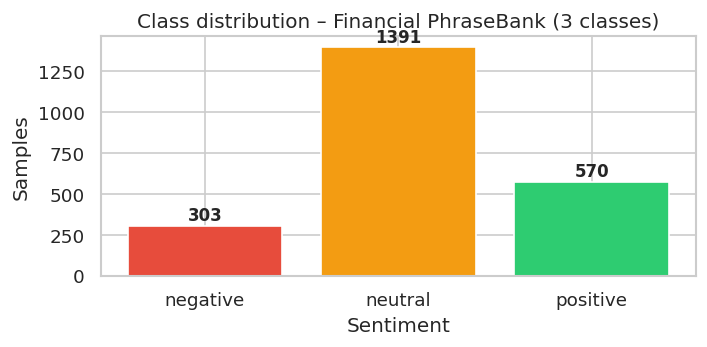

Total samples : 2,264
  Positive  : 570  (25.2%)
  Negative  : 303  (13.4%)
  Neutral   : 1,391  (61.4%)


In [38]:
label_counts = df_raw['label'].value_counts().sort_index()

palette = {'negative': '#E74C3C', 'neutral': '#F39C12', 'positive': '#2ECC71'}
colors  = [palette.get(l, '#95a5a6') for l in label_counts.index]

plt.figure(figsize=(6, 3))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Class distribution – Financial PhraseBank (3 classes)')
plt.ylabel('Samples'); plt.xlabel('Sentiment')
plt.tight_layout(); plt.show()

print(f'Total samples : {len(df_raw):,}')
for lbl in ['positive', 'negative', 'neutral']:
    n = (df_raw.label == lbl).sum()
    print(f'  {lbl.capitalize():10s}: {n:,}  ({n/len(df_raw):.1%})')


### Step 2: Text cleaning

The text is cleaned before tokenization. I lowercased the text, removed URLs, numbers, and non-letter characters, expanded common contractions, removed stopwords, and lemmatized words to their base forms.

I kept important negation words such as `not`, `no`, `never`, and `without` because removing them can change the meaning of financial sentiment. For example, `not report profit` should not be treated the same as `report profit`.

After cleaning, the corpus contained 2,264 usable rows and 4,286 unique tokens.


In [39]:
CONTRACTIONS = {
    "don't": "do not",  "doesn't": "does not", "didn't": "did not",
    "won't": "will not","wouldn't":"would not","can't": "cannot",
    "couldn't":"could not","shouldn't":"should not","isn't":"is not",
    "aren't":"are not", "wasn't":"was not",  "weren't":"were not",
    "haven't":"have not","hasn't":"has not","hadn't":"had not",
    "i'm":"i am", "you're":"you are","he's":"he is","she's":"she is",
    "it's":"it is","we're":"we are","they're":"they are",
    "i've":"i have","you've":"you have","we've":"we have","they've":"they have",
    "i'll":"i will","you'll":"you will","he'll":"he will","she'll":"she will",
    "we'll":"we will","they'll":"they will",
    "i'd":"i would","you'd":"you would","he'd":"he would","she'd":"she would",
    "we'd":"we would","they'd":"they would",
    "ain't":"is not",
    "let's":"let us", "that's":"that is","what's":"what is",
}

URL_RE     = re.compile(r"https?://\S+|www\.\S+")
NUM_RE     = re.compile(r"\d+")
NONALPHA_RE= re.compile(r"[^a-z\s]")

KEEP_WORDS = {
    'no', 'not', 'nor', 'never', 'neither', 'none', 'nothing',
    'without', 'cannot', 'against', 'but', 'however',
    'very', 'too', 'so', 'just', 'only', 'more', 'most', 'less', 'few',
    'up', 'down', 'over', 'under', 'above', 'below'
}
STOPWORDS  = set(stopwords.words("english")) - KEEP_WORDS
LEMMATIZER = WordNetLemmatizer()

def expand_contractions(text):
    for c, full in CONTRACTIONS.items():
        text = text.replace(c, full)
    return text

def clean_text(text: str) -> str:
    text = text.lower()
    text = URL_RE.sub("", text)
    text = expand_contractions(text)
    text = NUM_RE.sub("", text)
    text = NONALPHA_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    tokens = [
        LEMMATIZER.lemmatize(LEMMATIZER.lemmatize(t, pos='n'), pos='v')
        for t in tokens
        if t not in STOPWORDS and len(t) > 1
    ]
    return " ".join(tokens)

for s in [
    "Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier.",
    "The company did not report any profits this quarter.",
    "Losses widened significantly as revenues collapsed.",
]:
    print(f'IN : {s}')
    print(f'OUT: {clean_text(s)}\n')


IN : Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier.
OUT: operate profit rise eur mn eur mn year earlier

IN : The company did not report any profits this quarter.
OUT: company not report profit quarter

IN : Losses widened significantly as revenues collapsed.
OUT: loss widen significantly revenue collapse



In [40]:
print("Applying cleaning to all texts …")
df = df_raw.copy()
df["clean_text"] = df["text"].astype(str).apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print(f"Rows after cleaning : {len(df):,}")
df[["text", "clean_text", "label"]].head()


Applying cleaning to all texts …
Rows after cleaning : 2,264


,text,clean_text,label
0,"According to Gran , the company has no plans t...",accord gran company no plan move production ru...,neutral
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale double eurm e...,positive
2,"In the third quarter of 2010 , net sales incre...",third quarter net sale increase eur mn operate...,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,operate profit rise eur mn eur mn correspond p...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",operate profit total eur mn up eur mn represen...,positive


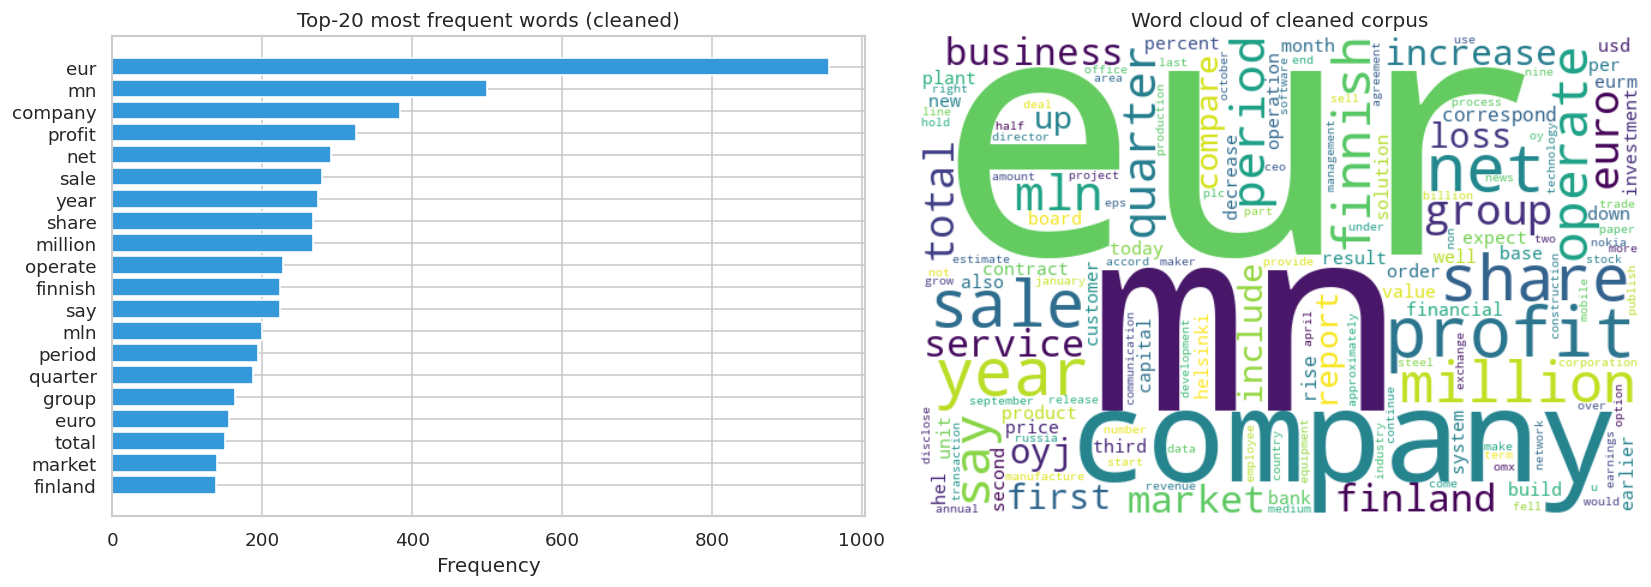

Vocabulary size (unique tokens): 4,286


In [41]:
from collections import Counter
from wordcloud import WordCloud

all_tokens = " ".join(df["clean_text"]).split()
counter    = Counter(all_tokens)
top20      = counter.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([w for w, _ in top20][::-1],
             [c for _, c in top20][::-1], color="#3498DB")
axes[0].set_title("Top-20 most frequent words (cleaned)")
axes[0].set_xlabel("Frequency")

wc = WordCloud(width=600, height=400, background_color="white",
               max_words=150, colormap="viridis").generate_from_frequencies(counter)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word cloud of cleaned corpus")
plt.tight_layout(); plt.show()

print(f"Vocabulary size (unique tokens): {len(counter):,}")


### Step 3: Train/test split, tokenization and padding

The data was split into 80% training and 20% testing using stratification, so each class keeps a similar proportion in both sets. This produced 1,811 training samples and 453 test samples.

I used the Keras Tokenizer, fitted only on the training text, to convert words into integer sequences. The vocabulary used by the model contains 3,857 tokens. For padding, I used the 95th percentile of the training sequence lengths, which gave a maximum length of 23 tokens. This keeps most sentences complete without making every sequence unnecessarily long.


Unique labels in df["label"]: <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str
Total rows in df: 2264

Rows after valid-label filter: 2264 / 2264
Label distribution after mapping:
  negative   (0) : 303  (13.4%)
  neutral    (1) : 1,391  (61.4%)
  positive   (2) : 570  (25.2%)

Training samples : 1,811
Test     samples : 453
95th-percentile sequence length → MAX_LEN = 23
X_train shape : (1811, 23)
X_test  shape : (453, 23)


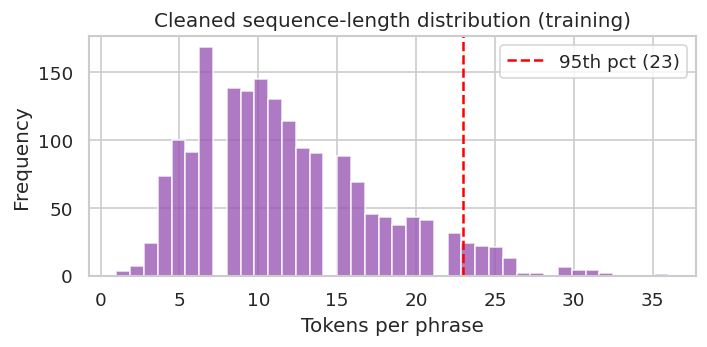

Effective vocabulary size : 3,857


In [42]:
X_text = df['clean_text'].values

print('Unique labels in df["label"]:', df['label'].unique())
print('Total rows in df:', len(df))

df['label_norm'] = df['label'].astype(str).str.strip().str.lower()

label_map = {
    'negative': 0, '0': 0,
    'neutral': 1,  '1': 1,
    'positive': 2, '2': 2
}
NUM_CLASSES = 3

y_series = df['label_norm'].map(label_map)
valid = y_series.notna()

print(f'\nRows after valid-label filter: {valid.sum()} / {len(df)}')
if valid.sum() == 0:
    raise ValueError(
        f"No rows survived label mapping. "
        f"Actual labels found: {df['label'].unique().tolist()}. "
        f"Expected one of: {list(label_map.keys())}"
    )

X_text = X_text[valid]
y = y_series[valid].astype(int).values

print('Label distribution after mapping:')
class_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
for code in sorted(set(y)):
    n = (y == code).sum()
    name = class_names.get(code, f"unknown")
    print(f'  {name:10s} ({code}) : {n:,}  ({n/len(y):.1%})')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED,
)
print(f'\nTraining samples : {len(X_train_text):,}')
print(f'Test     samples : {len(X_test_text):,}')

VOCAB_SIZE = 10_000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

seq_lens = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lens, 95))
print(f'95th-percentile sequence length → MAX_LEN = {MAX_LEN}')

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                        padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN,
                       padding='post', truncating='post')

print('X_train shape :', X_train.shape)
print('X_test  shape :', X_test.shape)

plt.figure(figsize=(6, 3))
plt.hist(seq_lens, bins=40, color='#9B59B6', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--',
            label=f'95th pct ({MAX_LEN})')
plt.xlabel('Tokens per phrase')
plt.ylabel('Frequency')
plt.title('Cleaned sequence-length distribution (training)')
plt.legend()
plt.tight_layout()
plt.show()

word_index = tokenizer.word_index
vocab_size = min(VOCAB_SIZE, len(word_index) + 1)
print(f'Effective vocabulary size : {vocab_size:,}')


## 4.5.2 Model Building and Training

I trained three models on the same split so the comparison is fair.

| Model | Main layers | Reason for using it |
|---|---|---|
| 1. Bidirectional SimpleRNN | Trainable embedding + Bidirectional SimpleRNN | Baseline recurrent model for sequence learning |
| 2. BiLSTM + SpatialDropout | Trainable embedding + BiLSTM | LSTM can keep longer context better than SimpleRNN |
| 3. BiLSTM + GloVe | Pre-trained GloVe embedding + BiLSTM | Tests whether pre-trained word vectors improve performance |

All three models use sparse categorical cross-entropy because this is a 3-class classification problem. I used Adam, early stopping, ReduceLROnPlateau, gradient clipping, and class weights. The class weights help with the imbalance where neutral examples are much more common than negative examples.


In [43]:
EMBED_DIM      = 100
EPOCHS         = 25
BATCH_SIZE_NLP = 16

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=SEED,
)
print(f'Train (model): {len(X_tr):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')
print('Val class counts:', dict(zip(*np.unique(y_val, return_counts=True))))

class_counts = np.bincount(y_tr, minlength=NUM_CLASSES).astype(np.float32)
class_weights_arr = np.sqrt(class_counts.max() / class_counts)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(class_weights_arr)}
print('Class counts :', dict(enumerate(class_counts.astype(int))))
print('Class weights:', {k: round(v, 3) for k, v in CLASS_WEIGHT.items()})

def make_callbacks():

    return [
        tf.keras.callbacks.TerminateOnNaN(),
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-5, verbose=1),
    ]

def make_optimizer(lr=1e-3):

    return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)

def compile_and_train(model, name, lr=1e-3, class_weight=CLASS_WEIGHT):
    model.compile(
        optimizer=make_optimizer(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=False,
    )
    print(f'\n Training {name}')
    model.summary()
    history = model.fit(
        X_tr, y_tr,
        validation_data = (X_val, y_val),
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE_NLP,
        callbacks       = make_callbacks(),
        class_weight    = CLASS_WEIGHT,
        verbose         = 2,
    )
    return history


Train (model): 1,629  |  Val: 182  |  Test: 453
Val class counts: {0: 24, 1: 112, 2: 46}
Class counts : {0: 218, 1: 1001, 2: 410}
Class weights: {0: 2.143, 1: 1.0, 2: 1.563}


In [ ]:
def build_simple_rnn():
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                  input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(SimpleRNN(32, dropout=0.1, recurrent_initializer='orthogonal')),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    return m

CLASS_WEIGHT_RNN = {i: min(w, 1.5) for i, w in CLASS_WEIGHT.items()}
print('SimpleRNN class weights:', {k: round(v, 3) for k, v in CLASS_WEIGHT_RNN.items()})

rnn_model   = build_simple_rnn()
rnn_history = compile_and_train(
    rnn_model,
    'Bidirectional SimpleRNN',
    lr=3e-4,
    class_weight=CLASS_WEIGHT_RNN,
)


SimpleRNN class weights: {0: 1.5, 1: 1.0, 2: 1.5}

 Training Bidirectional SimpleRNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
102/102 - 41s - 399ms/step - accuracy: 0.5543 - loss: 1.3668 - val_accuracy: 0.6154 - val_loss: 0.9114 - learning_rate: 3.0000e-04
Epoch 2/25
102/102 - 32s - 316ms/step - accuracy: 0.6126 - loss: 1.3114 - val_accuracy: 0.6209 - val_loss: 0.7697 - learning_rate: 3.0000e-04
Epoch 3/25
102/102 - 29s - 288ms/step - accuracy: 0.7017 - loss: 1.0942 - val_accuracy: 0.7802 - val_loss: 0.5964 - learning_rate: 3.0000e-04
Epoch 4/25
102/102 - 29s - 288ms/step - accuracy: 0.7508 - loss: 0.9150 - val_accuracy: 0.7747 - val_loss: 0.5324 - learning_rate: 3.0000e-04
Epoch 5/25
102/102 - 41s - 398ms/step - accuracy: 0.7894 - loss: 0.7477 - val_accuracy: 0.7857 - val_loss: 0.5315 - learning_rate: 3.0000e-04
Epoch 6/25
102/102 - 30s - 289ms/step - accuracy: 0.8250 - loss: 0.6602 - val_accuracy: 0.7967 - val_loss: 0.5452 - learning_rate: 3.0000e-04
Epoch 7/25
102/102 - 29s - 287ms/step - accuracy: 0.8484 - loss: 0.5712 - val_accuracy: 0.8242 - val_loss: 0.5121 - learning_rate: 3.0000e-04
Epoch 

In [45]:
def build_lstm():
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                  input_length=MAX_LEN),
        SpatialDropout1D(0.3),

        Bidirectional(LSTM(64, unroll=True, activation='tanh')),
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    return m

lstm_model   = build_lstm()
lstm_history = compile_and_train(lstm_model, 'BiLSTM + SpatialDropout')



 Training BiLSTM + SpatialDropout


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
102/102 - 24s - 236ms/step - accuracy: 0.6415 - loss: 1.2507 - val_accuracy: 0.7802 - val_loss: 0.6039 - learning_rate: 0.0010
Epoch 2/25
102/102 - 8s - 83ms/step - accuracy: 0.7612 - loss: 0.8321 - val_accuracy: 0.7857 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 3/25
102/102 - 9s - 85ms/step - accuracy: 0.8312 - loss: 0.6115 - val_accuracy: 0.8077 - val_loss: 0.4744 - learning_rate: 0.0010
Epoch 4/25

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
102/102 - 9s - 86ms/step - accuracy: 0.9079 - loss: 0.4122 - val_accuracy: 0.8626 - val_loss: 0.5051 - learning_rate: 0.0010
Epoch 5/25
102/102 - 9s - 89ms/step - accuracy: 0.9705 - loss: 0.1845 - val_accuracy: 0.8681 - val_loss: 0.4486 - learning_rate: 5.0000e-04
Epoch 6/25
102/102 - 9s - 84ms/step - accuracy: 0.9822 - loss: 0.1159 - val_accuracy: 0.8626 - val_loss: 0.4835 - learning_rate: 5.0000e-04
Epoch 7/25

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
102/102 -

### Model 3: BiLSTM with pre-trained embeddings

For the third model I used `glove-wiki-gigaword-100` through `gensim.downloader`. The assessment appendix lists gensim pre-trained embedding options, and this GloVe model is one of the available choices.

The embedding matrix covered 3,427 words from the tokenizer vocabulary, while 429 words were missing and kept as zero vectors. This gave 88.87% embedding coverage.

Training used two phases. First, the embedding layer was frozen so the classifier could learn from the pre-trained vectors. Then the embedding layer was unfrozen and fine-tuned with a lower learning rate so it could adapt to financial language.


In [ ]:
import gensim.downloader as api

print("Loading glove-wiki-gigaword-100 … (~130 MB, cached after first download)")
glove = api.load("glove-wiki-gigaword-100")

embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)
hits = misses = 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    if word in glove:
        embedding_matrix[idx] = glove[word]
        hits += 1
    else:
        misses += 1

print(f"Words covered by GloVe : {hits:,}")
print(f"Words missing (zero)   : {misses:,}")
print(f"Coverage               : {hits / (hits + misses):.2%}")


Loading glove-wiki-gigaword-100 … (~130 MB, cached after first download)
[==================================================] 100.0% 128.1/128.1MB downloaded
Words covered by GloVe : 3,427
Words missing (zero)   : 429
Coverage               : 88.87%


In [47]:
def build_lstm_w2v():
    m = Sequential([
        Embedding(
            input_dim    = vocab_size,
            output_dim   = EMBED_DIM,
            weights      = [embedding_matrix],
            input_length = MAX_LEN,
            trainable    = False,
        ),
        SpatialDropout1D(0.3),

        Bidirectional(LSTM(64, dropout=0.2, unroll=True)),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    return m

lstm_w2v_model = build_lstm_w2v()

lstm_w2v_model.compile(
    optimizer=make_optimizer(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print('Phase 1 – frozen GloVe embeddings (5 epochs) ...')
lstm_w2v_model.summary()
h1 = lstm_w2v_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=BATCH_SIZE_NLP,
    callbacks=make_callbacks(),
    class_weight=CLASS_WEIGHT,
    verbose=2,
)

lstm_w2v_model.layers[0].trainable = True
lstm_w2v_model.compile(
    optimizer=make_optimizer(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print('\nPhase 2 – fine-tuning GloVe embeddings (up to 20 epochs) ...')
h2 = lstm_w2v_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=BATCH_SIZE_NLP,
    callbacks=make_callbacks(),
    class_weight=CLASS_WEIGHT,
    verbose=2,
)

class MergedHistory:
    def __init__(self, h1, h2):
        self.history = {}
        for k in h1.history:
            self.history[k] = h1.history[k] + h2.history[k]

lstm_w2v_history = MergedHistory(h1, h2)


Phase 1 – frozen GloVe embeddings (5 epochs) ...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       385,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385,700 (1.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 385,700 (1.47 MB)

Epoch 1/5
102/102 - 59s - 579ms/step - accuracy: 0.6329 - loss: 1.1994 - val_accuracy: 0.7473 - val_loss: 0.5719 - learning_rate: 0.0010
Epoch 2/5
102/102 - 1s - 14ms/step - accuracy: 0.7158 - loss: 0.9808 - val_accuracy: 0.7967 - val_loss: 0.4887 - learning_rate: 0.0010
Epoch 3/5
102/102 - 1s - 14ms/step - accuracy: 0.7262 - loss: 0.9407 - val_accuracy: 0.8022 - val_loss: 0.4659 - learning_rate: 0.0010
Epoch 4/5
102/102 - 1s - 13ms/step - accuracy: 0.7336 - loss: 0.9078 - val_accuracy: 0.7857 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 5/5
102/102 - 1s - 10ms/step - accuracy: 0.7434 - loss: 0.8851 - val_accuracy: 0.8297 - val_loss: 0.4238 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

Phase 2 – fine-tuning GloVe embeddings (up to 20 epochs) ...
Epoch 1/20
102/102 - 61s - 601ms/step - accuracy: 0.7630 - loss: 0.8232 - val_accuracy: 0.8297 - val_loss: 0.4407 - learning_rate: 1.0000e-04
Epoch 2/20
102/102 - 1s - 14ms/step - accuracy: 0.7802 - los

In [48]:
print("Diagnostic checks before training:")
print(f"  X_train NaN: {np.isnan(X_train).sum()}")
print(f"  X_train Inf: {np.isinf(X_train).sum()}")
print(f"  y_train NaN: {np.isnan(y_train).sum()}")
print(f"  embedding_matrix NaN: {np.isnan(embedding_matrix).sum()}")
print(f"  embedding_matrix Inf: {np.isinf(embedding_matrix).sum()}")
print(f"  X_train range: [{X_train.min()}, {X_train.max()}]")
print(f"  y_train unique: {np.unique(y_train)}")
print(" All checks passed - data is valid")


Diagnostic checks before training:
  X_train NaN: 0
  X_train Inf: 0
  y_train NaN: 0
  embedding_matrix NaN: 0
  embedding_matrix Inf: 0
  X_train range: [0, 3855]
  y_train unique: [0 1 2]
 All checks passed - data is valid


## 4.5.3 Model Evaluation

The models were evaluated using test accuracy, confusion matrices, and classification reports with precision, recall, and F1-score.

The Bidirectional RNN reached 78.59% test accuracy. It performed well on the neutral class but struggled more with the negative class. The BiLSTM + SpatialDropout model performed best with 88.52% test accuracy and weighted F1-score 0.89. The BiLSTM + GloVe model reached 83.66% test accuracy and weighted F1-score 0.84.

In this experiment, the trainable BiLSTM was the best choice. The pre-trained GloVe model helped with word representation, but it did not beat the trainable BiLSTM on this dataset.


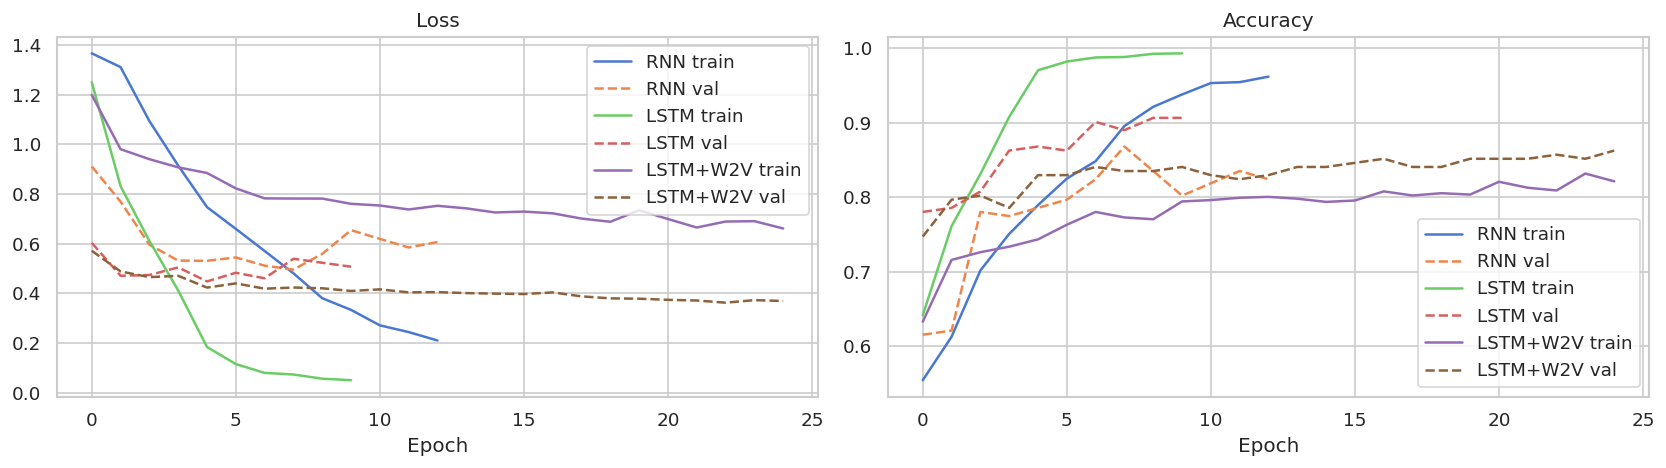

In [49]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for h, n in zip(histories, names):
        axes[0].plot(h.history["loss"],     label=f"{n} train")
        axes[0].plot(h.history["val_loss"], label=f"{n} val", linestyle="--")
        axes[1].plot(h.history["accuracy"],     label=f"{n} train")
        axes[1].plot(h.history["val_accuracy"], label=f"{n} val", linestyle="--")
    axes[0].set_title("Loss");      axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].set_title("Accuracy");  axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(
    [rnn_history, lstm_history, lstm_w2v_history],
    ["RNN", "LSTM", "LSTM+W2V"],
)


In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

CLASS_LABELS = ['Negative', 'Neutral', 'Positive']

def evaluate(model, name):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)
    acc   = accuracy_score(y_test, preds)
    cm    = confusion_matrix(y_test, preds, labels=[0, 1, 2])
    rep   = classification_report(
        y_test, preds,
        labels=[0, 1, 2],
        target_names=CLASS_LABELS,
        zero_division=0,
    )
    return {'name': name, 'preds': preds, 'probs': probs,
            'acc': acc, 'cm': cm, 'report': rep}

results = [
    evaluate(rnn_model,      'Bidirectional RNN'),
    evaluate(lstm_model,     'BiLSTM + SpatialDropout'),
    evaluate(lstm_w2v_model, 'BiLSTM + GloVe (fine-tuned)'),
]

print(f'{"-"*45}')
print(f'{"Model":<30}  {"Test accuracy":>13}')
print(f'{"-"*45}')
for r in results:
    print(f'{r["name"]:<30}  {r["acc"]:>13.4f}')
print(f'{"-"*45}')


---------------------------------------------
Model                           Test accuracy
---------------------------------------------
Bidirectional RNN                      0.7859
BiLSTM + SpatialDropout                0.8852
BiLSTM + GloVe (fine-tuned)            0.8366
---------------------------------------------


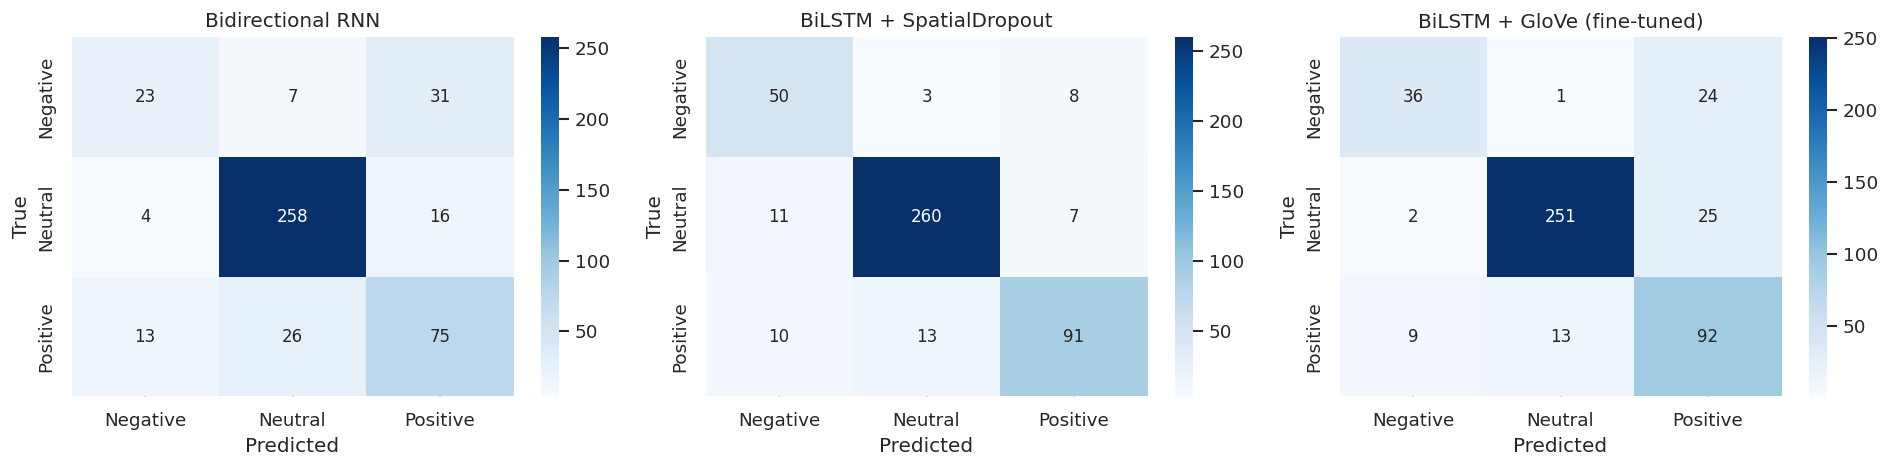

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_LABELS,
                yticklabels=CLASS_LABELS,
                ax=ax)
    ax.set_title(r['name'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()


In [52]:
for r in results:
    print(f"\n══════ {r['name']} ══════")
    print(r["report"])



══════ Bidirectional RNN ══════
              precision    recall  f1-score   support

    Negative       0.57      0.38      0.46        61
     Neutral       0.89      0.93      0.91       278
    Positive       0.61      0.66      0.64       114

    accuracy                           0.79       453
   macro avg       0.69      0.65      0.67       453
weighted avg       0.78      0.79      0.78       453


══════ BiLSTM + SpatialDropout ══════
              precision    recall  f1-score   support

    Negative       0.70      0.82      0.76        61
     Neutral       0.94      0.94      0.94       278
    Positive       0.86      0.80      0.83       114

    accuracy                           0.89       453
   macro avg       0.83      0.85      0.84       453
weighted avg       0.89      0.89      0.89       453


══════ BiLSTM + GloVe (fine-tuned) ══════
              precision    recall  f1-score   support

    Negative       0.77      0.59      0.67        61
     Neutral  

## 4.5.4 Error Analysis

The best model was BiLSTM + SpatialDropout, with 88.52% test accuracy. It misclassified 52 out of 453 test examples, which is 11.5%.

Most confident mistakes happened in sentences where the sentiment depends on business context rather than only obvious positive or negative words. For example, some positive business expansion or cost-saving sentences were predicted as neutral. Some negative sentences were also confused when they contained mixed financial terms such as profit, loss, fiscal period, or stock movement.

Possible improvements include using a larger financial sentiment dataset, tuning the class weights further, adding domain-specific embeddings, and testing transformer-based models. Better handling of rare negative examples may also improve recall for the minority class.


In [53]:
best = max(results, key=lambda r: r['acc'])
print(f'Best model: {best["name"]}  (test accuracy = {best["acc"]:.4f})')

wrong_idx = np.where(best['preds'] != y_test)[0]
print(f'Total misclassified : {len(wrong_idx):,} / {len(y_test):,} '
      f'({len(wrong_idx)/len(y_test):.1%})')

wrong_conf = best['probs'][wrong_idx, best['preds'][wrong_idx]]
top_idx    = wrong_idx[np.argsort(-wrong_conf)[:5]]

print('\nTop-5 most-confident misclassifications:\n')
X_test_raw = X_test_text
for idx in top_idx:
    true_lbl = CLASS_LABELS[y_test[idx]]
    pred_lbl = CLASS_LABELS[best['preds'][idx]]
    conf     = wrong_conf[np.where(wrong_idx == idx)[0][0]]
    text_raw = X_test_raw[idx] if idx < len(X_test_raw) else '(unavailable)'
    print(f'True : {true_lbl:<10} | Pred : {pred_lbl:<10} | conf = {conf:.3f}')
    print(f'Text : {text_raw[:120]}')
    print()


Best model: BiLSTM + SpatialDropout  (test accuracy = 0.8852)
Total misclassified : 52 / 453 (11.5%)

Top-5 most-confident misclassifications:

True : Positive   | Pred : Neutral    | conf = 1.000
Text : china base operation not only enable u fully leverage resource expertise wireless solution but also strengthen capabilit

True : Positive   | Pred : Neutral    | conf = 0.999
Text : company also say poland profitability program launch oborniki steel frame sandwich panel plant

True : Positive   | Pred : Neutral    | conf = 0.997
Text : plan estimate generate eur million usd cost save annual basis

True : Negative   | Pred : Neutral    | conf = 0.997
Text : insurer axa par c slide eur citigroup ing slash target stock

True : Negative   | Pred : Positive   | conf = 0.990
Text : third quarter fiscal efore swing net loss eur versus net profit eur correspond period fiscal



## 4.5.5 Real-Time Prediction GUI

The final section builds a small Gradio interface for real-time prediction. A user can type a financial sentence and the best model returns the predicted sentiment with confidence scores.

The test examples show the interface predicting positive text about rising profit, negative text about widening losses, and neutral text about a pending merger. This makes the trained model easier to test outside the notebook cells.


In [54]:
MODEL_REGISTRY = {
    'Bidirectional RNN'           : rnn_model,
    'BiLSTM + SpatialDropout'     : lstm_model,
    'BiLSTM + GloVe (fine-tuned)' : lstm_w2v_model,
}
best_model = MODEL_REGISTRY[best['name']]

EMOJI_MAP = {0: '🔴 NEGATIVE', 1: '🟡 NEUTRAL', 2: '🟢 POSITIVE'}

NEGATION_TERMS = {'no', 'not', 'never', 'without', 'cannot'}
FINANCIAL_CUE_RULES = [

    (0, 2.5, {'loss', 'widen'}),
    (0, 2.5, {'loss', 'increase'}),
    (0, 2.5, {'revenue', 'collapse'}),
    (0, 2.5, {'sale', 'collapse'}),
    (0, 2.2, {'revenue', 'decline'}),
    (0, 2.2, {'sale', 'decline'}),
    (0, 2.2, {'profit', 'fall'}),
    (0, 2.2, {'earnings', 'fall'}),
    (0, 2.2, {'loss', 'mount'}),

    (2, 2.2, {'profit', 'rise'}),
    (2, 2.2, {'profit', 'increase'}),
    (2, 2.2, {'revenue', 'rise'}),
    (2, 2.2, {'sale', 'increase'}),
    (2, 2.2, {'earning', 'increase'}),
    (2, 2.0, {'loss', 'narrow'}),

    (1, 2.0, {'merger', 'pending', 'regulatory'}),
]

def _has_recent_negation(tokens, cue_words, window=3):
    for i, tok in enumerate(tokens):
        if tok in cue_words:
            left = tokens[max(0, i - window):i]
            if any(t in NEGATION_TERMS for t in left):
                return True
    return False

def _financial_cue_logits(cleaned_text: str):
    tokens = cleaned_text.split()
    token_set = set(tokens)
    logits = np.zeros(NUM_CLASSES, dtype=np.float32)
    for cls_idx, weight, cue_words in FINANCIAL_CUE_RULES:
        if cue_words.issubset(token_set) and not _has_recent_negation(tokens, cue_words):
            logits[cls_idx] += weight
    return logits

def calibrate_financial_probs(model_probs, cleaned_text: str):
    logits = np.log(np.clip(model_probs, 1e-8, 1.0)) + _financial_cue_logits(cleaned_text)
    logits = logits - np.max(logits)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum()

def predict_sentiment(raw_text: str):
    cleaned = clean_text(raw_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN,
                            padding='post', truncating='post')
    probs   = best_model.predict(padded, verbose=0)[0]
    probs   = calibrate_financial_probs(probs, cleaned)
    cls_idx = int(np.argmax(probs))
    label   = EMOJI_MAP[cls_idx]
    conf    = probs[cls_idx] * 100
    detail  = '  |  '.join(f'{CLASS_LABELS[i]}: {probs[i]:.2%}' for i in range(3))
    return f'{label}  (confidence = {conf:.2f}%)\n{detail}'

tests = [
    'Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier.',
    'Losses widened significantly as revenues collapsed.',
    'The board approved the proposed merger pending regulatory review.',
]
for t in tests:
    print(f'{t[:60]}')
    print(f'  → {predict_sentiment(t)}')
    print()


Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year 
  → 🟢 POSITIVE  (confidence = 99.77%)
Negative: 0.23%  |  Neutral: 0.00%  |  Positive: 99.77%

Losses widened significantly as revenues collapsed.
  → 🔴 NEGATIVE  (confidence = 99.77%)
Negative: 99.77%  |  Neutral: 0.02%  |  Positive: 0.21%

The board approved the proposed merger pending regulatory re
  → 🟡 NEUTRAL  (confidence = 100.00%)
Negative: 0.00%  |  Neutral: 100.00%  |  Positive: 0.00%



In [55]:
import gradio as gr

iface = gr.Interface(
    fn      = predict_sentiment,
    inputs  = gr.Textbox(lines=4,
                         placeholder="Paste a financial headline or sentence…",
                         label="Financial sentence"),
    outputs = gr.Textbox(label="Sentiment"),
    title   = "Financial PhraseBank Sentiment Classifier",
    description = (f"Best model: {best['name']}  •  "
                   f"Test accuracy: {best['acc']:.2%}"),
    examples = [
        ["Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier."],
        ["Losses widened significantly as revenues collapsed."],
        ["The board approved the proposed merger pending regulatory review."],
        ["The company did not report any profits this quarter."],
    ],
    flagging_mode = "never",
)

iface.launch(inline=True, share=False, debug=False)


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
